In [62]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [63]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def mse(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean((y_true[mask] - y_pred[mask]) ** 2)

def mape(y_true, y_pred): 
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask])))


def qlike(test_actuals, test_preds): 
    test_actuals = np.asarray(test_actuals, dtype=float)
    test_preds = np.asarray(test_preds, dtype=float)

    test_qlike = np.mean(test_actuals / (test_preds + 1e-10) - np.log(test_actuals / (test_preds + 1e-10)) - 1)

    return test_qlike 

In [64]:
# test results from garch
test_garch = pd.read_csv('benchmark garch/garch.csv')
test_garch['var_garch_bench'] = np.exp(test_garch['var_garch_bench'])
test_garch['actual_var'] = np.exp(test_garch['actual_var'])

garch_rmse = rmse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mse = mse(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_mape = mape(test_garch['actual_var'], test_garch['var_garch_bench'])
garch_qlike = qlike(test_garch['actual_var'], test_garch['var_garch_bench'])

garch_rmse, garch_mse, garch_mape, garch_qlike

(np.float64(0.0006515314758416832),
 np.float64(4.244932640124419e-07),
 np.float64(0.00040337506799161763),
 np.float64(0.43333737612205614))

In [65]:
# test results from svr
test_svr = pd.read_csv('SVR/results/svr_test_results.csv')

svr_rmse = rmse(test_svr['actual_var'], test_svr['pred_var'])
svr_mse = mse(test_svr['actual_var'], test_svr['pred_var'])
svr_mape = mape(test_svr['actual_var'], test_svr['pred_var'])
svr_qlike = qlike(test_svr['actual_var'], test_svr['pred_var'])

svr_rmse, svr_mse, svr_mape, svr_qlike

(np.float64(0.0006559127349776613),
 np.float64(4.302215159058758e-07),
 np.float64(0.00039421141675018373),
 np.float64(0.45253174412718045))

In [66]:
# test result from lstm-svr new
test_lstmsvr = pd.read_csv('lstm-regimeaware/results/lstm-svr3.csv')
test_lstmsvr['var_svr'] = np.exp(test_lstmsvr['log_var_svr'])
test_lstmsvr['actual_var'] = np.exp(test_lstmsvr['actual_log_var'])

lstmsvr_rmse = rmse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mse = mse(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_mape = mape(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])
lstmsvr_qlike = qlike(test_lstmsvr['actual_var'], test_lstmsvr['var_svr'])

lstmsvr_rmse, lstmsvr_mse, lstmsvr_mape, lstmsvr_qlike


(np.float64(0.0006277285645398611),
 np.float64(3.940431507392745e-07),
 np.float64(0.0003722255310860858),
 np.float64(0.4042667842209255))

In [67]:
# test results from rf-svr new
test_rfsvr = pd.read_csv('rf-regimeaware/results/rf-svr3_results.csv')
test_rfsvr['var_svr'] = np.exp(test_rfsvr['log_var_svr'])
test_rfsvr['actual_var'] = np.exp(test_rfsvr['actual_log_var'])

rfsvr_rmse = rmse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mse = mse(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_mape = mape(test_rfsvr['actual_var'], test_rfsvr['var_svr'])
rfsvr_qlike = qlike(test_rfsvr['actual_var'], test_rfsvr['var_svr'])

rfsvr_rmse, rfsvr_mse, rfsvr_mape, rfsvr_qlike

(np.float64(0.0006185566076714076),
 np.float64(3.826122768939596e-07),
 np.float64(0.00037744702998631757),
 np.float64(0.4078125268061125))

In [68]:
# test results from HMM-svr
test_hmmsvr = pd.read_csv('2_step_hmm_model/results/hmm_svrl_revised_test_results.csv')

hmmsvr_rmse = rmse(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_mse = mse(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_mape = mape(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])
hmmsvr_qlike = qlike(test_hmmsvr['actual_var'], test_hmmsvr['forecast_var'])

hmmsvr_rmse, hmmsvr_mse, hmmsvr_mape, hmmsvr_qlike


(np.float64(0.0006455496913434246),
 np.float64(4.1673440399359075e-07),
 np.float64(0.000386757853864017),
 np.float64(0.4466729323527257))

In [78]:
# put all into a df 

results_df = pd.DataFrame({
    "Model": ["GARCH", "SVR", "LSTM-SVR", "RF-SVR", "HMM-SVR"],
    "RMSE": [garch_rmse, svr_rmse, lstmsvr_rmse, rfsvr_rmse, hmmsvr_rmse],
    "MSE":  [garch_mse,  svr_mse,  lstmsvr_mse,  rfsvr_mse, hmmsvr_mse],
    "MAPE": [garch_mape, svr_mape, lstmsvr_mape, rfsvr_mape, hmmsvr_mape],
    "QLIKE":[garch_qlike, svr_qlike, lstmsvr_qlike, rfsvr_qlike, hmmsvr_qlike]
})

print(results_df)

      Model      RMSE           MSE      MAPE     QLIKE
0     GARCH  0.000652  4.244933e-07  0.000403  0.433337
1       SVR  0.000656  4.302215e-07  0.000394  0.452532
2  LSTM-SVR  0.000628  3.940432e-07  0.000372  0.404267
3    RF-SVR  0.000619  3.826123e-07  0.000377  0.407813
4   HMM-SVR  0.000646  4.167344e-07  0.000387  0.446673


In [79]:
print(results_df.sort_values(by="QLIKE", ascending=True))

      Model      RMSE           MSE      MAPE     QLIKE
2  LSTM-SVR  0.000628  3.940432e-07  0.000372  0.404267
3    RF-SVR  0.000619  3.826123e-07  0.000377  0.407813
0     GARCH  0.000652  4.244933e-07  0.000403  0.433337
4   HMM-SVR  0.000646  4.167344e-07  0.000387  0.446673
1       SVR  0.000656  4.302215e-07  0.000394  0.452532


In [70]:
test_hmmsvr['date'] = pd.to_datetime(test_hmmsvr['date']) + pd.Timedelta(days=1)
test_hmmsvr['forecast_origin_date'] = pd.to_datetime(test_hmmsvr['forecast_origin_date']) + pd.Timedelta(days=1)
test_hmmsvr['date'] = test_hmmsvr['date'].dt.strftime('%Y-%m-%d')
test_hmmsvr['forecast_origin_date'] = test_hmmsvr['forecast_origin_date'].dt.strftime('%Y-%m-%d')

In [72]:
# Prepare data for DM test

# test_garch: drop error column, keep date and var_garch_bench
dm_garch = test_garch[['date', 'var_garch_bench']].copy()
dm_garch.columns = ['date', 'pred_var_garch']

# test_svr: rename pred_var to pred_var_svr, keep only date and pred_var_svr
dm_svr = test_svr[['date', 'pred_var']].copy()
dm_svr.columns = ['date', 'pred_var_svr']

# test_lstmsvr: rename var_svr to pred_var_lstmsvr, keep only date and pred_var_lstmsvr
dm_lstmsvr = test_lstmsvr[['date', 'var_svr']].copy()
dm_lstmsvr.columns = ['date', 'pred_var_lstmsvr']

# test_rfsvr: rename var_svr to pred_var_rfsvr, keep pred_var_rfsvr and date
dm_rfsvr = test_rfsvr[['date', 'var_svr']].copy()
dm_rfsvr.columns = ['date', 'pred_var_rfsvr']

# test_hmmsvr: rename forecast_var to pred_hmmsvr, keep pred_hmmsvr and date
dm_hmmsvr = test_hmmsvr[['date', 'forecast_var']].copy()
dm_hmmsvr.columns = ['date', 'pred_hmmsvr']

# Create merged dataframe with inner join on date
dm_combined = dm_garch.copy()
dm_combined = dm_combined.merge(dm_svr, on='date', how='inner')
dm_combined = dm_combined.merge(dm_lstmsvr, on='date', how='inner')
dm_combined = dm_combined.merge(dm_rfsvr, on='date', how='inner')
dm_combined = dm_combined.merge(dm_hmmsvr, on='date', how='inner')

print(f"Combined DM data shape: {dm_combined.shape}")
print(dm_combined.head())

Combined DM data shape: (469, 6)
         date  pred_var_garch  pred_var_svr  pred_var_lstmsvr  pred_var_rfsvr  \
0  2024-10-20        0.000666      0.000259          0.000231        0.000145   
1  2024-10-21        0.000697      0.000414          0.000550        0.000395   
2  2024-10-22        0.000685      0.000506          0.000610        0.000735   
3  2024-10-23        0.000546      0.000515          0.000494        0.000513   
4  2024-10-24        0.000604      0.000517          0.000486        0.000354   

   pred_hmmsvr  
0     0.000503  
1     0.000243  
2     0.000380  
3     0.000570  
4     0.000432  


In [73]:
from scipy import stats

def diebold_mariano_test(actual, pred_benchmark, pred_alternative, loss_function='mse'):
    """
    Diebold-Mariano test for equal predictive ability between two forecasts.
    
    Parameters:
    -----------
    actual : array-like
        Actual values
    pred_benchmark : array-like
        Predictions from benchmark model
    pred_alternative : array-like
        Predictions from alternative model
    loss_function : str
        Loss function to use: 'mse', 'mae', 'mape', 'qlike'
    
    Returns:
    --------
    dm_stat : float
        DM test statistic
    p_value : float
        Two-tailed p-value
    """
    
    # Convert to arrays and handle NaN values
    actual = np.asarray(actual, dtype=float)
    pred_benchmark = np.asarray(pred_benchmark, dtype=float)
    pred_alternative = np.asarray(pred_alternative, dtype=float)
    
    mask = np.isfinite(actual) & np.isfinite(pred_benchmark) & np.isfinite(pred_alternative)
    
    actual = actual[mask]
    pred_benchmark = pred_benchmark[mask]
    pred_alternative = pred_alternative[mask]
    
    # Calculate loss differentials
    if loss_function == 'mse':
        loss_bench = (actual - pred_benchmark) ** 2
        loss_alt = (actual - pred_alternative) ** 2
    elif loss_function == 'mae':
        loss_bench = np.abs(actual - pred_benchmark)
        loss_alt = np.abs(actual - pred_alternative)
    elif loss_function == 'mape':
        loss_bench = np.abs((actual - pred_benchmark) / actual)
        loss_alt = np.abs((actual - pred_alternative) / actual)
    elif loss_function == 'qlike':
        loss_bench = actual / (pred_benchmark + 1e-10) - np.log(actual / (pred_benchmark + 1e-10)) - 1
        loss_alt = actual / (pred_alternative + 1e-10) - np.log(actual / (pred_alternative + 1e-10)) - 1
    else:
        raise ValueError(f"Unknown loss function: {loss_function}")
    
    # Loss differential
    loss_diff = loss_bench - loss_alt
    
    # Mean loss differential
    mean_diff = np.mean(loss_diff)
    
    # Variance of loss differential (using Newey-West HAC estimator with lag=1)
    n = len(loss_diff)
    var_diff = 0
    
    for lag in range(n):
        if lag == 0:
            var_diff += np.sum((loss_diff - mean_diff) ** 2)
        else:
            cov = np.sum((loss_diff[lag:] - mean_diff) * (loss_diff[:-lag] - mean_diff))
            var_diff += 2 * (1 - lag / n) * cov
    
    var_diff = var_diff / n
    
    # Handle case where variance is zero or negative
    if var_diff <= 0:
        var_diff = np.var(loss_diff)
    
    # DM statistic
    if var_diff > 0:
        dm_stat = mean_diff / np.sqrt(var_diff / n)
    else:
        dm_stat = 0
    
    # P-value (two-tailed)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))
    
    return dm_stat, p_value, mean_diff


print("DM test function defined successfully")

DM test function defined successfully


In [ ]:
# DM Test 1: GARCH (benchmark) vs SVR, LSTM-SVR, RF-SVR, HMM-SVR

# Get actual variance (from original data)
actual_var = test_garch['actual_var'].values

print("=" * 80)
print("DM Test 1: GARCH (Benchmark) vs Other Models")
print("=" * 80)

# Test against SVR
dm_stat, p_value, mean_diff = diebold_mariano_test(
    actual_var, 
    dm_garch['pred_var_garch'].values, 
    dm_combined['pred_var_svr'].values, 
    loss_function='mse'
)
print(f"\nGARCH vs SVR (MSE Loss):")
print(f"  DM Statistic: {dm_stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Mean Loss Difference: {mean_diff:.6f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

# Test against LSTM-SVR
dm_stat, p_value, mean_diff = diebold_mariano_test(
    actual_var, 
    dm_garch['pred_var_garch'].values, 
    dm_combined['pred_var_lstmsvr'].values, 
    loss_function='mse'
)
print(f"\nGARCH vs LSTM-SVR (MSE Loss):")
print(f"  DM Statistic: {dm_stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Mean Loss Difference: {mean_diff:.6f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

# Test against RF-SVR
dm_stat, p_value, mean_diff = diebold_mariano_test(
    actual_var, 
    dm_garch['pred_var_garch'].values, 
    dm_combined['pred_var_rfsvr'].values, 
    loss_function='mse'
)
print(f"\nGARCH vs RF-SVR (MSE Loss):")
print(f"  DM Statistic: {dm_stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Mean Loss Difference: {mean_diff:.6f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

# Test against HMM-SVR
dm_stat, p_value, mean_diff = diebold_mariano_test(
    actual_var, 
    dm_garch['pred_var_garch'].values, 
    dm_combined['pred_hmmsvr'].values, 
    loss_function='mse'
)
print(f"\nGARCH vs HMM-SVR (MSE Loss):")
print(f"  DM Statistic: {dm_stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Mean Loss Difference: {mean_diff:.6f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

DM Test 1: GARCH (Benchmark) vs Other Models

GARCH vs SVR (MSE Loss):
  DM Statistic: -0.403284
  P-value: 0.686740
  Mean Loss Difference: -0.000000
  Significant at 5%: No

GARCH vs LSTM-SVR (MSE Loss):
  DM Statistic: 1.926672
  P-value: 0.054021
  Mean Loss Difference: 0.000000
  Significant at 5%: No

GARCH vs RF-SVR (MSE Loss):
  DM Statistic: 2.828080
  P-value: 0.004683
  Mean Loss Difference: 0.000000
  Significant at 5%: Yes

GARCH vs HMM-SVR (MSE Loss):
  DM Statistic: -3.199789
  P-value: 0.001375
  Mean Loss Difference: -0.000000
  Significant at 5%: Yes


In [75]:
# DM Test 2: RF-SVR (benchmark) vs LSTM-SVR and HMM-SVR

print("\n" + "=" * 80)
print("DM Test 2: RF-SVR (Benchmark) vs LSTM-SVR and HMM-SVR")
print("=" * 80)

# Test against LSTM-SVR
dm_stat, p_value, mean_diff = diebold_mariano_test(
    actual_var, 
    dm_combined['pred_var_rfsvr'].values, 
    dm_combined['pred_var_lstmsvr'].values, 
    loss_function='mse'
)
print(f"\nRF-SVR vs LSTM-SVR (MSE Loss):")
print(f"  DM Statistic: {dm_stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Mean Loss Difference: {mean_diff:.6f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")

# Test against HMM-SVR
dm_stat, p_value, mean_diff = diebold_mariano_test(
    actual_var, 
    dm_combined['pred_var_rfsvr'].values, 
    dm_combined['pred_hmmsvr'].values, 
    loss_function='mse'
)
print(f"\nRF-SVR vs HMM-SVR (MSE Loss):")
print(f"  DM Statistic: {dm_stat:.6f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Mean Loss Difference: {mean_diff:.6f}")
print(f"  Significant at 5%: {'Yes' if p_value < 0.05 else 'No'}")


DM Test 2: RF-SVR (Benchmark) vs LSTM-SVR and HMM-SVR

RF-SVR vs LSTM-SVR (MSE Loss):
  DM Statistic: -1.470108
  P-value: 0.141533
  Mean Loss Difference: -0.000000
  Significant at 5%: No

RF-SVR vs HMM-SVR (MSE Loss):
  DM Statistic: -3.240480
  P-value: 0.001193
  Mean Loss Difference: -0.000000
  Significant at 5%: Yes


In [76]:
# Directional accuracy test (hit rate)

actual_var = test_garch[['date', 'actual_var']].copy()
hit_rate_df = actual_var.merge(dm_combined, on='date', how='inner')

# 1) Actual day-to-day change in realized volatility
hit_rate_df["actual_change"] = hit_rate_df["actual_var"].diff()

# 2) Forecasted day-to-day change for each model
model_cols = {
    "GARCH": "pred_var_garch",
    "SVR": "pred_var_svr",
    "LSTM-SVR": "pred_var_lstmsvr",
    "RF-SVR": "pred_var_rfsvr",
    "HMM-SVR": "pred_hmmsvr"
}

results = []

for model_name, col in model_cols.items():
    pred_change_col = f"{col}_change"
    hit_col = f"{col}_hit"
    
    # Predicted day-to-day change
    hit_rate_df[pred_change_col] = hit_rate_df[col].diff()
    
    # Keep only rows where both actual and predicted changes are non-missing
    temp = hit_rate_df[["actual_change", pred_change_col]].dropna().copy()
    
    # Optional: exclude zero-change cases since direction is ambiguous
    temp = temp[(temp["actual_change"] != 0) & (temp[pred_change_col] != 0)]
    
    # Hit = sign of predicted change matches sign of actual change
    temp[hit_col] = np.sign(temp["actual_change"]) == np.sign(temp[pred_change_col])
    
    n_obs = len(temp)
    n_hits = temp[hit_col].sum()
    hit_rate = n_hits / n_obs if n_obs > 0 else np.nan
    
    results.append({
        "Model": model_name,
        "Hits": int(n_hits) if pd.notna(hit_rate) else np.nan,
        "Total Valid Observations": n_obs,
        "Hit Rate": hit_rate,
        "Hit Rate (%)": hit_rate * 100 if pd.notna(hit_rate) else np.nan
    })

# 3) Results table
hit_rate_results = pd.DataFrame(results)

# Format for display
hit_rate_results["Hit Rate"] = hit_rate_results["Hit Rate"].round(4)
hit_rate_results["Hit Rate (%)"] = hit_rate_results["Hit Rate (%)"].round(2)

print(hit_rate_results)


      Model  Hits  Total Valid Observations  Hit Rate  Hit Rate (%)
0     GARCH   225                       468    0.4808         48.08
1       SVR   217                       468    0.4637         46.37
2  LSTM-SVR   202                       468    0.4316         43.16
3    RF-SVR   219                       468    0.4679         46.79
4   HMM-SVR   198                       468    0.4231         42.31


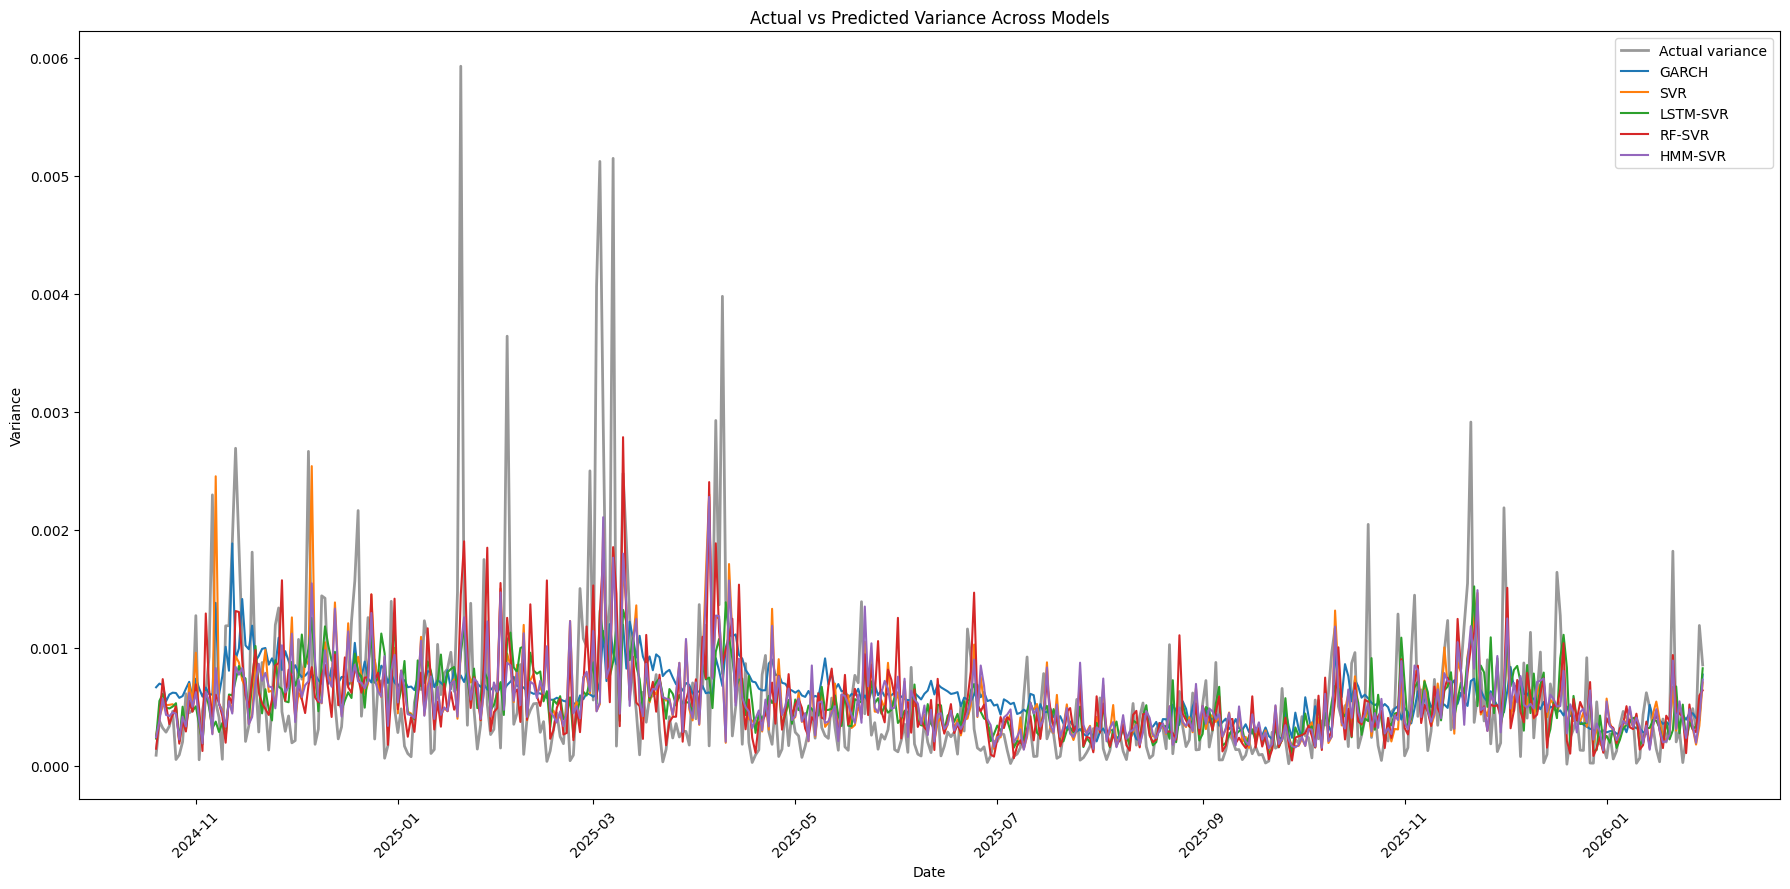

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read results
# -----------------------------
test_garch = pd.read_csv("benchmark garch/garch.csv")
test_svr = pd.read_csv("SVR/results/svr_test_results.csv")
test_lstmsvr = pd.read_csv("lstm-regimeaware/results/lstm-svr3.csv")
test_rfsvr = pd.read_csv("rf-regimeaware/results/rf-svr3_results.csv")
test_hmmsvr = pd.read_csv('2_step_hmm_model/results/hmm_svrl_revised_test_results.csv')

# -----------------------------
# 2. Convert to variance scale
# -----------------------------
test_garch["actual_var"] = np.exp(test_garch["actual_var"])
test_garch["pred_garch"] = np.exp(test_garch["var_garch_bench"])

test_svr["pred_svr"] = test_svr["pred_var"]

test_lstmsvr["actual_var"] = np.exp(test_lstmsvr["actual_log_var"])
test_lstmsvr["pred_lstmsvr"] = np.exp(test_lstmsvr["log_var_svr"])

test_rfsvr["actual_var"] = np.exp(test_rfsvr["actual_log_var"])
test_rfsvr["pred_rfsvr"] = np.exp(test_rfsvr["log_var_svr"])

# -----------------------------
# 3. Keep only needed columns
#    adjust "date" if your column name differs
# -----------------------------
garch_df = test_garch[["date", "actual_var", "pred_garch"]].copy()
svr_df = test_svr[["date", "actual_var", "pred_svr"]].copy()
lstm_df = test_lstmsvr[["date", "actual_var", "pred_lstmsvr"]].copy()
rf_df = test_rfsvr[["date", "actual_var", "pred_rfsvr"]].copy()
hmm_df = test_hmmsvr[["date", "actual_var", "forecast_var"]].copy()
hmm_df['date'] = pd.to_datetime(hmm_df['date']) 

# -----------------------------
# 4. Convert dates
# -----------------------------
for df in [garch_df, svr_df, lstm_df, rf_df]:
    df["date"] = pd.to_datetime(df["date"])

# -----------------------------
# 5. Merge everything on date
#    Use one actual_var column from one file
# -----------------------------
plot_df = (
    garch_df[["date", "actual_var", "pred_garch"]]
    .merge(svr_df[["date", "pred_svr"]], on="date", how="inner")
    .merge(lstm_df[["date", "pred_lstmsvr"]], on="date", how="inner")
    .merge(rf_df[["date", "pred_rfsvr"]], on="date", how="inner")
    .merge(hmm_df[["date", "forecast_var"]].rename(columns={"forecast_var": "pred_hmmsvr"}), on="date", how="inner")
    .sort_values("date")
)

# -----------------------------
# 6. Plot
# -----------------------------
plt.figure(figsize=(18, 9))
plt.plot(
    plot_df["date"],
    plot_df["actual_var"],
    label="Actual variance",
    color="black",
    linewidth=2,
    alpha=0.4
)

# models (clear colors)
plt.plot(plot_df["date"], plot_df["pred_garch"], label="GARCH")
plt.plot(plot_df["date"], plot_df["pred_svr"], label="SVR")
plt.plot(plot_df["date"], plot_df["pred_lstmsvr"], label="LSTM-SVR")
plt.plot(plot_df["date"], plot_df["pred_rfsvr"], label="RF-SVR")
plt.plot(plot_df["date"], plot_df["pred_hmmsvr"], label="HMM-SVR")

plt.title("Actual vs Predicted Variance Across Models")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()